# 변분 양자 고유값 풀이 (VQE)

VQE는 해밀토니안의 **가장 낮은 고유값**, 곧 바닥 에너지를 근사하는 양자–고전 하이브리드 알고리즘이다. 고유벡터를 한 번에 풀어내는 방법이 아니다. 매개변수 회로로 시험 상태를 만들고, 그 에너지 기댓값을 고전 최적화가 낮춘다.

이 노트북은 실장비를 쓰지 않는다. 회로가 만든 상태벡터에서
$\langle\psi(\vec\theta)|H|\psi(\vec\theta)\rangle$를 직접 계산한다.
큐 대기와 샷 노이즈가 없으므로, 알고리즘의 골격과 해밀토니안 사이의 차이만 남는다.

실장비 VQE와의 대응은 다음과 같다.

| 실장비 | 이 노트북 |
|---|---|
| 회로를 하드웨어에 올려 준비 | 같은 회로를 상태벡터에 적용 |
| Pauli 항을 묶어 측정 | $\psi^\dagger H\psi$를 선형대수로 계산 |
| 샷 평균의 통계 오차 | 해당 $\vec\theta$에서 정확한 기댓값 |
| 잡음 때문에 $E<E_0$가 가능 | 변분 원리 $E\ge E_0$가 그대로 성립 |


## 1. VQE의 네 조각

한 바퀴에 들어가는 것은 네 가지다.

* **해밀토니안** $H$. 계의 에너지를 나타내는 에르미트 연산자. 바닥 상태는 가장 낮은 고유값에 딸린 고유벡터다.
* **앙자츠**. 매개변수 $\vec\theta$를 받는 양자 회로. 시험 상태 $|\psi(\vec\theta)\rangle=U(\vec\theta)|0\rangle^{\otimes n}$를 만든다.
* **기댓값 계산**. 지금 상태에서 $E(\vec\theta)=\langle\psi|H|\psi\rangle$를 구한다. 실장비에서는 Pauli를 나눠 측정하고, 여기서는 상태벡터로 같은 값을 계산한다.
* **고전 최적화기**. $E(\vec\theta)$가 작아지도록 $\vec\theta$를 갱신한다.

각각을 조금 더 풀어 보자.


### 1.1 해밀토니안

물리에서 해밀토니안은 에너지 연산자다. 양자컴퓨팅에서는 경로나 비용 같은 최적화 문제를 같은 꼴의 에르미트 연산자로 옮겨 놓고도 해밀토니안이라 부른다. 어느 쪽이든 할 일은 같다. 가장 낮은 고유값을 찾는 것이다.

분자나 격자를 큐비트 Pauli 합으로 쓰는 일은 그 자체로 한 과목이다. 여기서는 이미

$$
H=\sum_{\ell}h_{\ell}P_{\ell},\qquad P_{\ell}\in\{I,X,Y,Z\}^{\otimes n}
$$

으로 적힌 연산자를 출발점으로 둔다. 항끼리 교환하지 않으면 실장비에서는 한 번에 잴 수 없다. 상태벡터로 기댓값을 구할 때는 그 제약이 사라지지만, 항의 구조는 그대로 $H$를 정의한다.

아래는 수소 분자 $\mathrm{H}_2$를 활성 공간 근사와 Jordan–Wigner 변환으로 옮긴 네 큐비트 연산자다. `YYYY`와 `ZZII`처럼 같은 큐비트에서 $Y$와 $Z$가 동시에 나타나는 항이 있어, 실장비라면 여러 측정 묶음이 필요하다.


In [14]:
from qiskit.quantum_info import SparsePauliOp

h2_hamiltonian = SparsePauliOp(
    [
        "IIII",
        "IIIZ",
        "IZII",
        "IIZI",
        "ZIII",
        "IZIZ",
        "IIZZ",
        "ZIIZ",
        "IZZI",
        "ZZII",
        "ZIZI",
        "YYYY",
        "XXYY",
        "YYXX",
        "XXXX",
    ],
    coeffs=[
        -0.09820182,
        -0.1740751,
        -0.1740751,
        0.2242933,
        0.2242933,
        0.16891402,
        0.1210099,
        0.16631441,
        0.16631441,
        0.1210099,
        0.17504456,
        0.04530451,
        0.04530451,
        0.04530451,
        0.04530451,
    ],
)

h2_hamiltonian


SparsePauliOp(['IIII', 'IIIZ', 'IZII', 'IIZI', 'ZIII', 'IZIZ', 'IIZZ', 'ZIIZ', 'IZZI', 'ZZII', 'ZIZI', 'YYYY', 'XXYY', 'YYXX', 'XXXX'],
              coeffs=[-0.09820182+0.j, -0.1740751 +0.j, -0.1740751 +0.j,  0.2242933 +0.j,
  0.2242933 +0.j,  0.16891402+0.j,  0.1210099 +0.j,  0.16631441+0.j,
  0.16631441+0.j,  0.1210099 +0.j,  0.17504456+0.j,  0.04530451+0.j,
  0.04530451+0.j,  0.04530451+0.j,  0.04530451+0.j])

이 연산자는 $16\times 16$ 행렬이라 고전 대각화가 전혀 어렵지 않다. VQE를 연습하는 이유는 이 크기가 아니라, $n$이 커져 $2^n$을 저장하지 못할 때도 같은 루프가 돌아가게 하기 위해서다.


In [15]:
import numpy as np

evals = np.linalg.eigvalsh(h2_hamiltonian.to_matrix())
print(f"Exact ground energy: {evals.min():.10f} hartree")
print(f"Number of terms: {len(h2_hamiltonian)}")


Exact ground energy: -1.1459778448 hartree
Number of terms: 15


### 1.2 앙자츠

앙자츠(Ansatz)는 시험 상태의 가족이다. 회로 안의 회전각이 $\vec\theta$이고, 각을 바꾸면 상태가 바뀐다. 큐비트는 보통 $|0\rangle^{\otimes n}$에서 시작한다.

$$
|\psi(\vec\theta)\rangle=U_{\mathrm{var}}(\vec\theta)|0\rangle^{\otimes n}
$$

에너지 기댓값은

$$
E(\vec\theta)=\langle\psi(\vec\theta)|H|\psi(\vec\theta)\rangle
$$

이다. 변분 원리 때문에 이 값은 진짜 바닥 에너지보다 낮아질 수 없다. $E$를 낮출수록, 그 앙자츠가 닿을 수 있는 범위 안에서 바닥에 가까워진다.

이미 계를 조금 알고 있다면 $|0\rangle^{\otimes n}$보다 나은 출발점을 쓸 수 있다. 화학에서는 Hartree–Fock 상태가 흔한 **기준 상태**다. 기준 회로를 $U_{\mathrm{ref}}$라 하면

$$
|\psi_{\mathrm{ansatz}}(\vec\theta)\rangle
=U_{\mathrm{var}}(\vec\theta)\,U_{\mathrm{ref}}|0\rangle^{\otimes n}.
$$

회로 가족이 바닥 상태를 포함하지 않으면, 최적화를 아무리 돌려도 간격이 남는다. 그 간격을 **앙자츠 오차**라 한다. 측정 횟수를 늘려도, 상태벡터로 기댓값을 정확히 계산해도, 이 오차는 줄지 않는다.


### 1.3 기댓값: 측정 대신 계산

$H$를 통째로 관측가능량처럼 한 샷에 읽을 수는 없다. 같은 큐비트의 $X,Y,Z$가 교환하지 않기 때문이다. 실장비에서는 $H$를 동시에 잴 수 있는 Pauli 묶음으로 쪼개고, 묶음마다 샷을 모아 표본 평균을 낸다.

$$
H=\sum_{\alpha}c_{\alpha}h_{\alpha}
\quad\Rightarrow\quad
\langle H\rangle=\sum_{\alpha}c_{\alpha}\langle h_{\alpha}\rangle
$$

통계 오차는 샷 수 $M$에 대해 대략 $O(1/\sqrt{M})$이다. 항이 많고 정밀도가 높으면, 최적화 **한 번**의 측정 비용이 이미 크다.

이 노트북은 그 과정을 상태벡터로 대체한다. 회로 $U(\vec\theta)$를 적용한 $|\psi\rangle$를 메모리에 두고

$$
E=\langle\psi|H|\psi\rangle=\psi^\dagger H\psi
$$

를 직접 곱한다. Qiskit의 `StatevectorEstimator`가 이 계산을 맡는다. 결과는 그 앙자츠와 매개변수에서 이론상 정확한 기댓값이다.

실장비와 같은 점은 $H$를 행렬로 넣어 고유계를 뽑지 않고, **현재 시험 상태의 기댓값만** 쓴다는 것이다. 다른 점은 그 기댓값을 표본이 아니라 선형대수로 구한다는 것이다.


### 1.4 고전 최적화기

최적화기는 $E(\vec\theta)$를 검은 상자로 본다. 인자를 조금 바꾸고 함수값을 받은 뒤, 다음 인자를 고른다.

* 기울기를 쓰는 방법: SLSQP, BFGS
* 함수값만 쓰는 방법: COBYLA, Nelder–Mead
* 잡음이 큰 실장비에서 자주 쓰는 방법: SPSA

SciPy `minimize`에 넘기는 것은 대략 다음과 같다.

* 최소화할 함수. 여기서는 에너지 기댓값
* 시작점 $x_0$
* 앙자츠, 해밀토니안, Estimator
* 방법 이름과 `maxiter`

상태벡터 계산에서는 함수값이 깨끗하므로 SLSQP도 잘 맞는다. 아래 예제는 반복마다 에너지가 하나씩 쌓여 수렴 곡선을 읽기 쉬운 **COBYLA**를 기본으로 둔다.


In [31]:
# # Syntax sketch. The real call is inside run_vqe in section 3.
# from scipy.optimize import minimize
# x0 = np.random.uniform(0.0, 2.0 * np.pi, size=ansatz.num_parameters)
# res = minimize(
#     cost_func,
#     x0,
#     args=(ansatz, hamiltonian, estimator, history),
#     method="COBYLA",
#     options={"maxiter": 200},
# )


### 1.5 변분 원리

정규화된 시험 상태에 대해

$$
E_{\mathrm{var}}=\langle\psi_{\mathrm{var}}|H|\psi_{\mathrm{var}}\rangle
\ge
E_0=\langle\psi_0|H|\psi_0\rangle
$$

이다. $H$의 고유상태 $\{|\psi_i\rangle\}$는 완전기저이므로 임의의 정규 상태를

$$
|\psi_{\mathrm{var}}\rangle=\sum_{i=0}c_i|\psi_i\rangle,
\qquad \sum_i|c_i|^2=1
$$

로 쓸 수 있다. 대입하면

\begin{aligned}
E_{\mathrm{var}}
&=\Bigl(\sum_i c_i^*\langle\psi_i|\Bigr)H\Bigl(\sum_j c_j|\psi_j\rangle\Bigr)
=\sum_{i,j}c_i^*c_j E_j\langle\psi_i|\psi_j\rangle
=\sum_i|c_i|^2 E_i \\
&\ge E_0\sum_i|c_i|^2
=E_0.
\end{aligned}

등호는 시험 상태가 바닥 고유공간에 있을 때만 성립한다. 따라서 **그 앙자츠 안에서** 변분 에너지를 가장 낮게 만드는 상태가 바닥에 가장 가까운 근사다.

**생각해 보기.** $|\psi\rangle=(|\psi_0\rangle+|\psi_1\rangle)/\sqrt{2}$이면 $E[\psi]$는 $E_0,E_1$의 평균이다. 변분 원리가 “에너지를 과소평가하지 않는다”는 말은 $E(\vec\theta)\ge E_0$ 한 줄로 다시 쓸 수 있다.


## 2. 고전이 비싼 지점

$N\times N$ 행렬과 $N$성분 벡터의 기댓값은 최악의 경우 곱셈 $O(N^2)$이다. 큐비트 $n$개면 $N=2^n$이라 $n$에 지수적이다. 매개변수 갱신 자체는 싸지만, 그 곱셈을 최적화 매 스텝마다 반복한다.

양자 쪽 서술은 이 기댓값을 측정으로 바꾼다. Pauli 행렬과 단위행렬은 주어진 차원의 연산자 공간을 생성하므로, 어떤 $H$든 Pauli 합으로 쓸 수 있다. 다만 모든 항을 동시에 재지는 못한다.

Qiskit Estimator가 가정하는 것은 **큐비트별 교환**(qubit-wise commuting)이다. 각 자리에서 두 Pauli가 같거나 한쪽이 $I$여야 한 묶음으로 잰다. `IZIZ`와 `ZZXZ`는 가능하고, `ZZZZ`와 `ZZZX`는 0번 큐비트의 $Z$와 $X$ 때문에 불가능하다. 두 문자열이 연산자로서 교환하더라도, 자리마다 교환하지 않으면 이 방식의 동시 측정에서는 빠진다.

묶음의 수 $N_{\mathrm{GCP}}$가 작으면 측정 비용이 버틸 만하다. 스핀 사슬이 이쪽에 가깝다. 분자 해밀토니안은 항이 수천에서 수백만까지 늘어나기도 해서, 측정 횟수 자체가 병목이 된다.

이 노트북의 상태벡터 계산은 $2^n$ 벡터를 메모리에 두므로, 큰 $n$에서는 고전 대각화와 같은 벽에 부딪힌다. 지금 규모에서 얻는 것은 루프의 구조와, 해밀토니안마다 앙자츠가 바닥에 얼마나 닿는가다.

**생각해 보기.** 네 큐비트 항

`IIXX`, `IIXZ`, `IIZZ`, `IZXZ`, `IXXZ`, `ZZXZ`, `XZXZ`, `ZIXZ`, `ZZZZ`, `XXXX`

을 큐비트별 교환 묶음으로 나누면 네 묶음이면 충분하다. 한 가지 해는

* `IIXX`, `XXXX`, `IIZZ`, `ZZZZ`
* `IIXZ`, `IZXZ`, `ZIXZ`, `ZZXZ`
* `IXXZ`
* `XZXZ`

이다. 화학 VQE에서 보통 더 아픈 쪽은 앙자츠를 못 찾는 일이 아니라, 항이 많아 측정이 폭발하는 일이다.


## 3. 상태벡터 VQE

공통 함수를 만든 뒤, 해밀토니안만 바꿔 같은 루프를 돌린다. 흐름은 실장비 튜토리얼의 “회로로 옮긴다 / 하드웨어에 맞춘다 / 실행한다 / 후처리한다”에서 하드웨어 단계를 뺀 것과 같다.

1. Pauli 합으로 $H$를 적는다.
2. `efficient_su2` 앙자츠를 고른다. 한 층은 $R_y$, $R_z$와 원형 CNOT이다.
3. `StatevectorEstimator`로 $E(\vec\theta)$를 계산한다.
4. COBYLA가 $\vec\theta$를 움직인다.
5. 같은 $H$를 `numpy.linalg.eigvalsh`로 대각화해 정확한 $E_0$와 비교한다.

작은 행렬을 고전으로 푸는 이유는 VQE를 검산하기 위해서다. 검산이 가능한 크기에서 루프가 맞는지 본 다음, 같은 코드에 더 복잡한 $H$를 넣는다.


In [17]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from qiskit.circuit.library import efficient_su2
from qiskit.primitives import StatevectorEstimator
from qiskit.quantum_info import SparsePauliOp

plt.rcParams["axes.unicode_minus"] = False

estimator = StatevectorEstimator()
runs = {}


def qubitwise_commute(p, q):
    return all(a == "I" or b == "I" or a == b for a, b in zip(p, q))


def n_commuting_groups(hamiltonian):
    """Number of qubit-wise commuting groups. A lower bound on hardware measurement cost."""
    groups = []
    for pauli in hamiltonian.paulis:
        label = pauli.to_label()
        placed = False
        for group in groups:
            if all(qubitwise_commute(label, other) for other in group):
                group.append(label)
                placed = True
                break
        if not placed:
            groups.append([label])
    return len(groups)


def exact_ground(hamiltonian):
    return float(np.min(np.linalg.eigvalsh(hamiltonian.to_matrix())))


def make_ansatz(n_qubits, reps=2):
    return efficient_su2(
        n_qubits,
        su2_gates=["ry", "rz"],
        entanglement="circular",
        reps=reps,
    )


def cost_func(params, ansatz, hamiltonian, history):
    energy = float(
        estimator.run([(ansatz, hamiltonian, params)]).result()[0].data.evs
    )
    history.append(energy)
    return energy


def run_vqe(name, hamiltonian, reps=2, maxiter=250, seed=0, method="COBYLA"):
    ansatz = make_ansatz(hamiltonian.num_qubits, reps=reps)
    rng = np.random.default_rng(seed)
    x0 = rng.uniform(0.0, 2.0 * np.pi, size=ansatz.num_parameters)
    history = []
    result = minimize(
        cost_func,
        x0,
        args=(ansatz, hamiltonian, history),
        method=method,
        options={"maxiter": maxiter},
    )
    e0 = exact_ground(hamiltonian)
    e_vqe = float(result.fun)
    summary = {
        "name": name,
        "hamiltonian": hamiltonian,
        "ansatz": ansatz,
        "e0": e0,
        "vqe": e_vqe,
        "error": abs(e_vqe - e0),
        "n_qubits": hamiltonian.num_qubits,
        "n_terms": len(hamiltonian),
        "n_groups": n_commuting_groups(hamiltonian),
        "n_params": ansatz.num_parameters,
        "nfev": len(history),
        "history": np.array(history, dtype=float),
        "opt_result": result,
    }
    runs[name] = summary
    print(f"{name}")
    print(f"  qubits={summary['n_qubits']}, Pauli terms={summary['n_terms']}, commuting groups={summary['n_groups']}")
    print(f"  parameters={summary['n_params']}, function evaluations={summary['nfev']}")
    print(f"  exact E0 = {e0:.8f}")
    print(f"  VQE energy = {e_vqe:.8f}")
    print(f"  |E - E0|   = {summary['error']:.3e}")
    return summary


def plot_history(summary, ax=None):
    if ax is None:
        _, ax = plt.subplots(figsize=(6.2, 3.6))
    ax.plot(summary["history"], color="#2F75B5", lw=1.8, label="VQE")
    ax.axhline(summary["e0"], color="#C00000", ls="--", lw=1.4, label=r"exact $E_0$")
    ax.set_xlabel("function evaluations")
    ax.set_ylabel("energy")
    ax.set_title(summary["name"])
    ax.legend(frameon=False)
    ax.grid(alpha=0.25)
    return ax


앙자츠 한 장을 그려 두면, 이후 예제가 같은 회로 가족을 쓴다는 점이 눈에 들어온다. 큐비트마다 $R_y$, $R_z$가 있고, 원형 CNOT이 한 층을 이룬다. `reps`를 늘리면 이 층이 반복되고 매개변수는 $2n(\mathrm{reps}+1)$개가 된다.


findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font famil

Number of parameters: 16


findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font famil

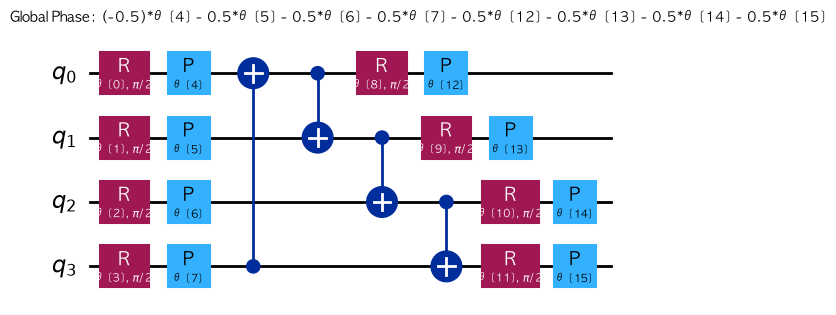

In [18]:
demo_ansatz = make_ansatz(4, reps=1)
print("Number of parameters:", demo_ansatz.num_parameters)
demo_ansatz.decompose().draw("mpl", style="iqp")


### 3.1 두 큐비트 연습

항이 네 개인 작은 연산자로 루프가 닫히는지 본다.

$$
H=0.3980\,YZ-0.3980\,ZI-0.0113\,ZZ+0.1810\,XX
$$

$YZ$와 $XX$가 교환하지 않으므로 실장비라면 측정 묶음이 둘 이상이다. 상태벡터에서는 그 차이가 기댓값을 쪼개는 일에만 나타나고, 최적화 자체는 한 개의 스칼라 $E(\vec\theta)$만 본다.


findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font famil

Two-qubit toy
  qubits=2, Pauli terms=4, commuting groups=3
  parameters=8, function evaluations=80
  exact E0 = -0.70293039
  VQE energy = -0.70255824
  |E - E0|   = 3.722e-04


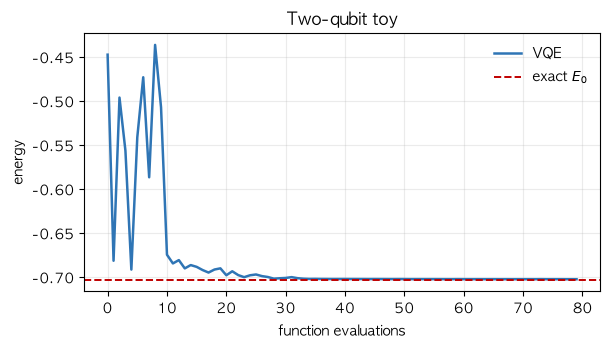

In [19]:
toy = SparsePauliOp.from_list(
    [("YZ", 0.3980), ("ZI", -0.3980), ("ZZ", -0.0113), ("XX", 0.1810)]
)
run_vqe("Two-qubit toy", toy, reps=1, maxiter=80, seed=1)
plot_history(runs["Two-qubit toy"])
plt.tight_layout()
plt.show()


### 3.2 두 자리 페르미온

스핀 없는 두 자리 모형

$$
H=-t\bigl(c_1^\dagger c_2+c_2^\dagger c_1\bigr)+\varepsilon(n_1+n_2)
$$

의 Jordan–Wigner 결과는

$$
H=-\frac t2(X_1X_2+Y_1Y_2)+\frac\varepsilon2(2I-Z_1-Z_2)
$$

이다. 한 전자 부분공간에서 정확한 바닥은 $\varepsilon-t$이고, 입자수를 지키는 한 매개변수 상태

$$
|\psi(\theta)\rangle=\cos\frac\theta2\,|10\rangle+\sin\frac\theta2\,|01\rangle
$$

를 넣으면 $E(\theta)=\varepsilon-t\sin\theta$가 된다. $\theta=\pi/2$에서 이미 정확한 바닥에 닿는다.

하드웨어 효율 회로는 이 부분공간을 강제로 지키지 않는다. $|00\rangle$과 $|11\rangle$으로 새면 같은 바닥에 닿기 위해 매개변수가 더 필요하다. 그래도 상태벡터 VQE가 $\varepsilon-t$ 근처로 내려가는지 보면, 앙자츠가 그 부분공간을 포함하는지가 드러난다.


findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font famil

Two-site fermion
  qubits=2, Pauli terms=5, commuting groups=3
  parameters=12, function evaluations=150
  exact E0 = -0.50000000
  VQE energy = -0.49975175
  |E - E0|   = 2.483e-04


findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font famil

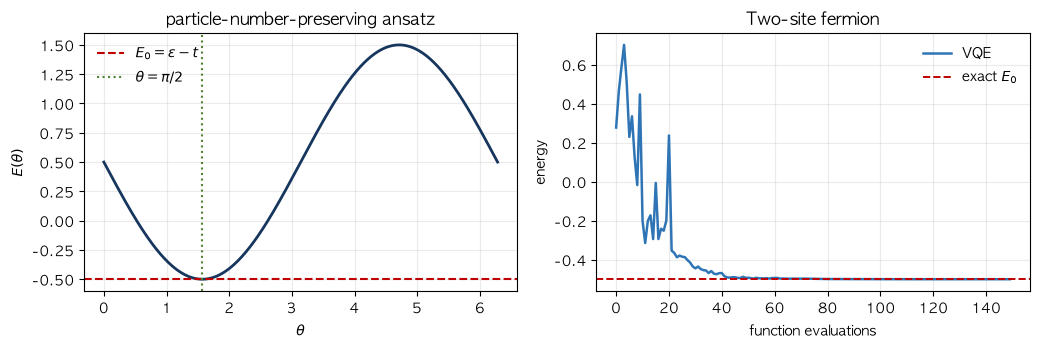

In [20]:
t, eps = 1.0, 0.5
fermion = SparsePauliOp.from_list(
    [
        ("II", eps),
        ("IZ", -eps / 2),
        ("ZI", -eps / 2),
        ("XX", -t / 2),
        ("YY", -t / 2),
    ]
)

theta = np.linspace(0, 2 * np.pi, 400)
analytic = eps - t * np.sin(theta)

fig, axes = plt.subplots(1, 2, figsize=(10.5, 3.6))
axes[0].plot(theta, analytic, color="#17365D", lw=2)
axes[0].axhline(eps - t, color="#C00000", ls="--", label=r"$E_0=\varepsilon-t$")
axes[0].axvline(np.pi / 2, color="#548235", ls=":", label=r"$\theta=\pi/2$")
axes[0].set_xlabel(r"$\theta$")
axes[0].set_ylabel(r"$E(\theta)$")
axes[0].set_title("particle-number-preserving ansatz")
axes[0].legend(frameon=False)
axes[0].grid(alpha=0.25)

run_vqe("Two-site fermion", fermion, reps=2, maxiter=150, seed=2)
plot_history(runs["Two-site fermion"], ax=axes[1])
plt.tight_layout()
plt.show()


### 3.3 수소 분자 $\mathrm{H}_2$

1절의 네 큐비트 연산자를 그대로 넣는다. 항이 15개이고 $YYYY$, $XXYY$, $YYXX$, $XXXX$처럼 네 큐비트에 가로로 걸린 교환 항이 있다. 큐비트별 교환 묶음은 항 수보다 적다. 실장비라면 그 묶음 수만큼 측정을 반복해야 하고, 여기서는 상태벡터 한 번으로 $\langle H\rangle$가 나온다.

화학적 정밀도는 대략 $1.6\times 10^{-3}$ hartree다. 네 큐비트에서는 고전 대각화가 훨씬 싸므로, 이 예제의 목적은 분자 해밀토니안의 **항 구조**를 VQE 루프에 태워 보는 것이다.


findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font famil

H2 molecule
  qubits=4, Pauli terms=15, commuting groups=5
  parameters=24, function evaluations=280
  exact E0 = -1.14597784
  VQE energy = -0.53239841
  |E - E0|   = 6.136e-01


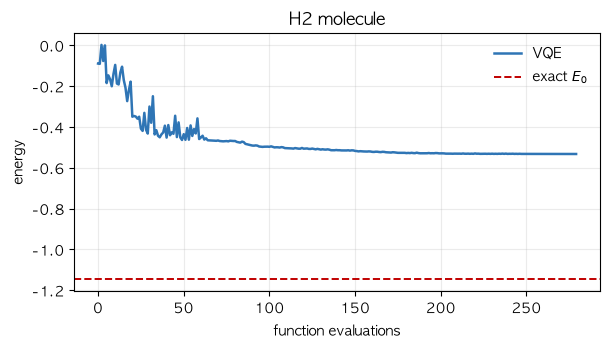

In [21]:
run_vqe("H2 molecule", h2_hamiltonian, reps=2, maxiter=280, seed=3)
plot_history(runs["H2 molecule"])
plt.tight_layout()
plt.show()


### 3.4 횡자기장 이징 모형 (TFIM)

열린 사슬

$$
H=-J\sum_{i=1}^{n-1}Z_i Z_{i+1}-h\sum_{i=1}^n X_i
$$

는 양자 자성의 기본 모형이다. $J$는 이웃이 같은 방향을 선호하게 하고, $h$는 스핀을 $x$축으로 눕힌다. $ZZ$와 $X$가 교환하지 않아 바닥 상태는 둘의 타협이다.

항 수는 $O(n)$이라 분자보다 훨씬 성기다. VQE가 스핀 모형에서 측정 부담이 상대적으로 작은 이유가 여기 있다. $n=4$, $J=1$, $h=1$로 둔다.


findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font famil

TFIM n=4
  qubits=4, Pauli terms=7, commuting groups=2
  parameters=24, function evaluations=300
  exact E0 = -4.75877048
  VQE energy = -4.03258046
  |E - E0|   = 7.262e-01


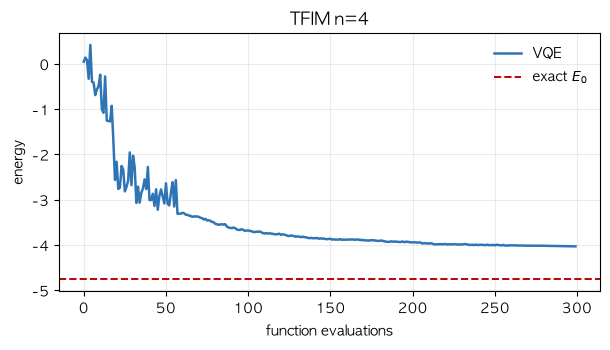

In [22]:
def transverse_ising(n, J=1.0, h=1.0):
    terms = [("ZZ", [i, i + 1], -J) for i in range(n - 1)]
    terms += [("X", [i], -h) for i in range(n)]
    return SparsePauliOp.from_sparse_list(terms, num_qubits=n)


tfim = transverse_ising(4, J=1.0, h=1.0)
run_vqe("TFIM n=4", tfim, reps=2, maxiter=300, seed=4)
plot_history(runs["TFIM n=4"])
plt.tight_layout()
plt.show()


### 3.5 하이젠베르크 XXX 사슬

$$
H=J\sum_{i=1}^{n-1}\bigl(X_i X_{i+1}+Y_i Y_{i+1}+Z_i Z_{i+1}\bigr)
$$

한 결합마다 $XX,YY,ZZ$가 모두 들어 있어, 그 세 항은 같은 두 큐비트에서 서로 교환하지 않는다. 실장비 측정 묶음은 결합당 적어도 셋이다. 등방 교환이라 바닥 상태는 총스핀이 작은 쪽으로 기울고, 열린 사슬 $n=4$의 정확한 값은 대각화로 바로 확인할 수 있다.

이징보다 상관 구조가 더 얽혀 있으므로, 같은 `reps=2` 앙자츠로도 오차가 남을 수 있다. 남는 간격이 있다면 그것은 보통 최적화 실패라기보다 회로 가족이 바닥을 덜 포함하는 쪽에 가깝다.


findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font famil

Heisenberg XXX n=4
  qubits=4, Pauli terms=9, commuting groups=3
  parameters=24, function evaluations=320
  exact E0 = -6.46410162
  VQE energy = -6.16112982
  |E - E0|   = 3.030e-01


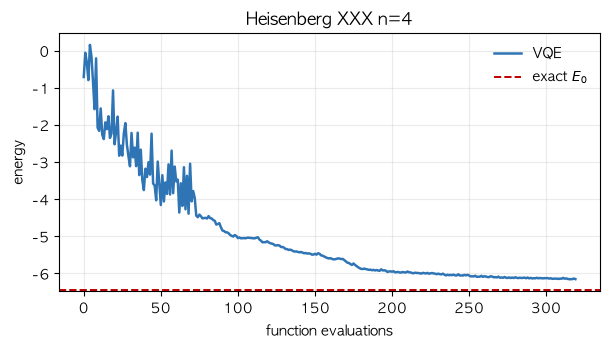

In [23]:
def heisenberg_xxx(n, J=1.0):
    terms = []
    for i in range(n - 1):
        for pauli in ("XX", "YY", "ZZ"):
            terms.append((pauli, [i, i + 1], J))
    return SparsePauliOp.from_sparse_list(terms, num_qubits=n)


heis = heisenberg_xxx(4, J=1.0)
run_vqe("Heisenberg XXX n=4", heis, reps=2, maxiter=320, seed=5)
plot_history(runs["Heisenberg XXX n=4"])
plt.tight_layout()
plt.show()


### 3.6 허바드 이합체

두 자리, 스핀 위·아래를 네 큐비트로 둔다. $0$은 자리 1의 $\uparrow$, $1$은 자리 1의 $\downarrow$, $2$는 자리 2의 $\uparrow$, $3$은 자리 2의 $\downarrow$다.

$$
H=-t\sum_{\sigma}\bigl(c_{1\sigma}^\dagger c_{2\sigma}+c_{2\sigma}^\dagger c_{1\sigma}\bigr)
+U\bigl(n_{1\uparrow}n_{1\downarrow}+n_{2\uparrow}n_{2\downarrow}\bigr)
$$

도약 항은 $XX+YY$ 꼴이고, 온사이트 척력은

$$
n_{\uparrow}n_{\downarrow}=\frac14(I-Z_{\uparrow})(I-Z_{\downarrow})
$$

이라 $ZZ$와 국소 $Z$가 생긴다. 전자 상관을 한 자리에 밀어 넣는 항이라, 하드웨어 효율 앙자츠가 입자수·스핀 부분공간을 지키지 않으면 앙자츠 오차가 이징보다 크게 남을 수 있다.

$t=1$, $U=2$로 둔다. VQE 에너지가 정확한 $E_0$ 위에서 멈추면, 그 간격은 변분 원리가 허용하는 앙자츠 오차로 읽으면 된다.


findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font famil

Hubbard dimer
  qubits=4, Pauli terms=11, commuting groups=3
  parameters=24, function evaluations=320
  exact E0 = -1.23606798
  VQE energy = -1.22814206
  |E - E0|   = 7.926e-03


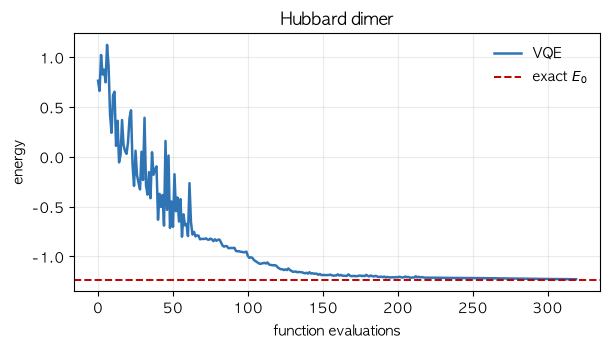

In [24]:
def hubbard_dimer(t=1.0, U=2.0):
    terms = [
        ("XX", [0, 2], -t / 2),
        ("YY", [0, 2], -t / 2),
        ("XX", [1, 3], -t / 2),
        ("YY", [1, 3], -t / 2),
        ("ZZ", [0, 1], U / 4),
        ("Z", [0], -U / 4),
        ("Z", [1], -U / 4),
        ("ZZ", [2, 3], U / 4),
        ("Z", [2], -U / 4),
        ("Z", [3], -U / 4),
        ("I", [0], U / 2),
    ]
    return SparsePauliOp.from_sparse_list(terms, num_qubits=4)


hubbard = hubbard_dimer(t=1.0, U=2.0)
run_vqe("Hubbard dimer", hubbard, reps=2, maxiter=320, seed=6)
plot_history(runs["Hubbard dimer"])
plt.tight_layout()
plt.show()


### 3.7 한 표로 비교

같은 앙자츠 가족, 같은 최적화기를 썼을 때 무엇이 달라지는지 모은다. 항의 수와 동시측정 묶음은 실장비 비용의 지표이고, $|E-E_0|$는 지금 회로가 바닥에 얼마나 닿았는지의 지표다.


findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font famil

model                   n terms groups  params          E0         VQE       error
----------------------------------------------------------------------------------
Two-qubit toy           2     4      3       8   -0.702930   -0.702558   3.722e-04
Two-site fermion        2     5      3      12   -0.500000   -0.499752   2.483e-04
H2 molecule             4    15      5      24   -1.145978   -0.532398   6.136e-01
TFIM n=4                4     7      2      24   -4.758770   -4.032580   7.262e-01
Heisenberg XXX n=4      4     9      3      24   -6.464102   -6.161130   3.030e-01
Hubbard dimer           4    11      3      24   -1.236068   -1.228142   7.926e-03


findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font famil

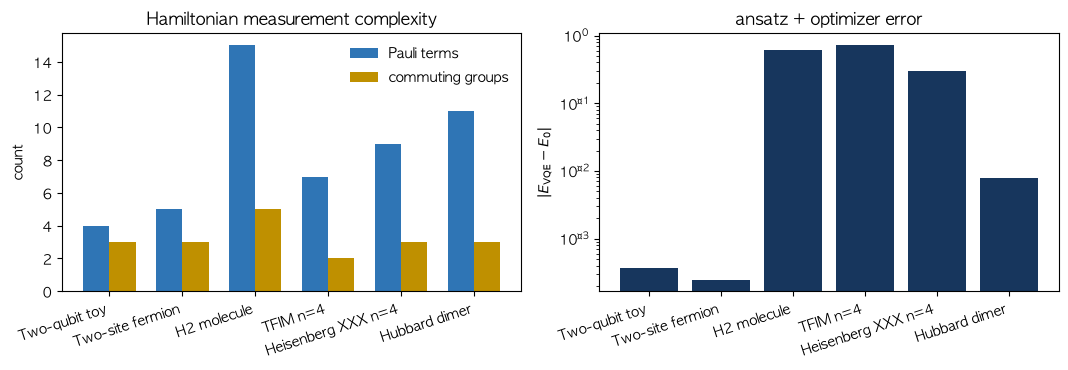

In [25]:
rows = list(runs.values())
print(f"{'model':<22}{'n':>3}{'terms':>6}{'groups':>7}{'params':>8}{'E0':>12}{'VQE':>12}{'error':>12}")
print("-" * 82)
for row in rows:
    print(
        f"{row['name']:<22}{row['n_qubits']:>3}{row['n_terms']:>6}"
        f"{row['n_groups']:>7}{row['n_params']:>8}"
        f"{row['e0']:>12.6f}{row['vqe']:>12.6f}{row['error']:>12.3e}"
    )

fig, axes = plt.subplots(1, 2, figsize=(10.8, 3.8))
names = [row["name"] for row in rows]
x = np.arange(len(rows))

axes[0].bar(x - 0.18, [row["n_terms"] for row in rows], width=0.36, color="#2F75B5", label="Pauli terms")
axes[0].bar(x + 0.18, [row["n_groups"] for row in rows], width=0.36, color="#BF9000", label="commuting groups")
axes[0].set_xticks(x, names, rotation=18, ha="right")
axes[0].set_ylabel("count")
axes[0].set_title("Hamiltonian measurement complexity")
axes[0].legend(frameon=False)

axes[1].bar(x, [row["error"] for row in rows], color="#17365D")
axes[1].set_xticks(x, names, rotation=18, ha="right")
axes[1].set_ylabel(r"$|E_{\mathrm{VQE}}-E_0|$")
axes[1].set_title("ansatz + optimizer error")
axes[1].set_yscale("log")

plt.tight_layout()
plt.show()


수렴이 아쉬운 모형은 층을 늘리거나, 시작점을 바꾸거나, SLSQP처럼 기울기를 쓰는 방법으로 한 번 더 내려가 볼 수 있다. 허바드처럼 간격이 크게 남으면 `reps`만 늘리기 전에, 입자수를 지키는 회로를 쓰는 편이 물리적으로 맞다.


findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font famil

Hubbard dimer reps=3
  qubits=4, Pauli terms=11, commuting groups=3
  parameters=32, function evaluations=360
  exact E0 = -1.23606798
  VQE energy = -0.98845753
  |E - E0|   = 2.476e-01


findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font famil

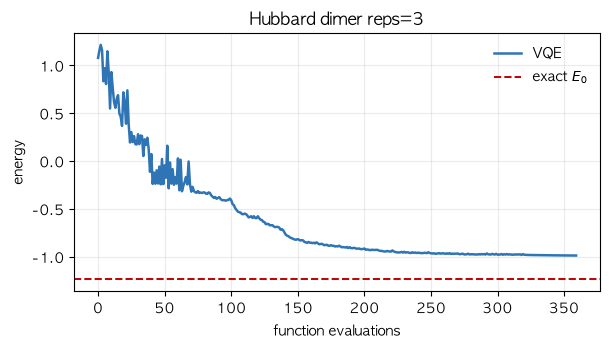

In [26]:
# Extra layer on Hubbard only, to see if the ansatz error shrinks.
run_vqe("Hubbard dimer reps=3", hubbard, reps=3, maxiter=360, seed=7)
plot_history(runs["Hubbard dimer reps=3"])
plt.tight_layout()
plt.show()


## 4. 잘 되는 점과 안 되는 점

**맞는 지점**

* 회로가 얕아도 루프가 성립한다. 위상 추정보다 깊이에 덜 민감하다.
* 고유값 문제로 적을 수 있는 스핀, 분자, 격자 모형에 같은 골격을 쓸 수 있다.
* 상태벡터로 돌리면 변분 원리 $E\ge E_0$가 수치로 바로 보인다.

**아픈 지점**

* 휴리스틱이다. 앙자츠가 바닥을 포함하지 않으면 최적화기가 아무리 좋아도 $E_0$에 닿지 않는다.
* 표현력을 위해 매개변수를 늘리면, 고전 탐색 공간이 같이 커진다.
* 실장비에서는 교환하지 않는 Pauli 묶음마다 측정을 반복한다. 분자처럼 항이 많은 $H$에서 이 비용이 먼저 터진다.
* 충분히 무작위인 깊은 회로에서는 기울기의 분산이 큐비트 수에 지수적으로 줄어든다. 이를 barren plateau라 한다. 국소 최솟값에 갇히는 것과 다르다. 신호가 사라져 방향을 구분하지 못하는 쪽에 가깝다.
* 변분 원리의 $E\ge E_0$는 **이상적인** 기댓값에 대한 정리이다. 실장비 잡음은 에너지를 과소평가할 수도 있다. 이 노트북의 계산은 그 왜곡을 넣지 않았다.

**다른 알고리즘과의 자리**

* **ADAPT-VQE**는 고정 회로 대신, 매 단계 에너지 기울기가 큰 연산자만 골라 앙자츠를 키운다. 회로는 짧아질 수 있지만, 기울기를 반복해서 구해야 한다.
* **위상 추정(QPE)**은 $e^{-iH\tau}$의 고유위상을 읽어 에너지를 얻는다. 정확도 $\varepsilon$에 회로 깊이가 대략 $O(1/\varepsilon)$이고, 오류 내성이 있는 장치를 전제한다. VQE는 깊이를 변분 회로로 바꾸고, 대가로 반복 측정과 고전 탐색을 낸다.
* **Krylov / SQD / SKQD**도 시험 상태를 쓰지만, 매개변수를 경사로 찾는 대신 양자 장치가 만든 부분공간에 $H$를 투영한 뒤 고전이 대각화한다. 다음 글의 SKQD가 이 갈래다.

VQE와 위의 방법들이 공유하는 것은 좋은 시험 상태다. VQE만의 특징은 고전 최적화기가 회로 각도를 직접 움직인다는 점이다.


## 5. 한 줄로

임의의 정규 상태에 대해 $\langle\psi|H|\psi\rangle\ge E_0$이다. VQE는 시험 상태를 $U(\vec\theta)|0\rangle$으로 제한한 함수 $E(\vec\theta)$를 낮춘다. 실장비는 그 값을 Pauli 측정으로 추정하고, 이 노트북은 상태벡터로 계산한다. 두 큐비트와 두 자리 페르미온에서는 바닥에 쉽게 닿고, 이징·하이젠베르크·분자·허바드로 갈수록 항의 교환 구조와 앙자츠 오차가 드러난다. 고유벡터를 푸는 일이 아니라, 측정 가능하거나 계산 가능한 에너지 곡면을 고전이 내려가는 일이다.
